# Deep Image Prior for Super-Resolution

Deep Image Prior (DIP) can be applied to the problem of super-resolution, where the goal is to upscale a low-resolution (LR) image to a higher resolution (HR) using a neural network. Unlike traditional methods that require pre-trained models, DIP uses a randomly initialized network and optimizes it to reconstruct the high-resolution image.

In this notebook, we will:
1. Set up the environment
2. Define the neural network architecture
3. Load and preprocess images
4. Train the network for super-resolution
5. Evaluate and display the results

Let's dive in!

**Importing Libraries**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Define the Neural Network

We will use a convolutional neural network for super-resolution. The network consists of several convolutional layers with ReLU activations.

Let's define the network.

In [17]:
import torch
import torch.nn as nn

# Define the DIPNet model
class DIPNet(nn.Module):
    def __init__(self):
        super(DIPNet, self).__init__()
        
        # Define the model as a Sequential container
        self.model = nn.Sequential(
            # First convolutional layer: 3 input channels -> 64 output channels
            nn.Conv2d(3, 64, kernel_size=5, padding=2),  
            nn.ReLU(),
            
            # Second convolutional layer: 64 -> 64
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            
            # Third convolutional layer: 64 -> 64
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            
            # Fourth convolutional layer: 64 -> 64
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            
            # Final convolutional layer: 64 -> 3 (back to RGB)
            nn.Conv2d(64, 3, kernel_size=5, padding=2),
            nn.ReLU(),
            
            # Upsample the output by a factor of 4 using bilinear interpolation
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)
        )
    
    def forward(self, x):
        # Forward pass through the model
        return self.model(x)


## 3. Load and Preprocess Images

We need to load the high-resolution image and create a low-resolution version by downsampling. Then, we'll prepare these images for training.

Let's load and preprocess the images.

In [18]:
# Function to load and preprocess an image
def load_image(image_path, size=(256, 256)):
    """
    Loads an image, resizes it, and converts it to a tensor.

    Parameters:
    - image_path (str): Path to the input image.
    - size (tuple): Desired size for resizing (width, height).

    Returns:
    - Tensor: Preprocessed image tensor (1, C, H, W) on the specified device.
    """
    image = Image.open(image_path).convert('RGB')  # Load image and ensure 3 channels (RGB)
    image = image.resize(size, Image.BICUBIC)      # Resize using bicubic interpolation
    transform = transforms.ToTensor()              # Convert to tensor (C, H, W) scaled to [0, 1]
    return transform(image).unsqueeze(0).to(device) # Add batch dimension and move to device

# Function to downsample an image tensor
def downsample(image, scale_factor):
    """
    Downsample an image by a given scale factor.

    Parameters:
    - image (Tensor): The image tensor to downsample (1, C, H, W).
    - scale_factor (float): The factor by which to downsample.

    Returns:
    - Tensor: Downsampled image tensor.
    """
    downsampled = torch.nn.functional.interpolate(
        image, 
        scale_factor=1/scale_factor, 
        mode='bilinear', 
        align_corners=False
    )
    return downsampled

# Function to add Gaussian noise to an image
def add_noise(image, noise_level=0.1):
    """
    Adds random Gaussian noise to an image tensor.

    Parameters:
    - image (Tensor): The image tensor.
    - noise_level (float): The standard deviation of the noise to add.

    Returns:
    - Tensor: Noisy image tensor.
    """
    noise = noise_level * torch.randn_like(image)  # Generate noise
    return image + noise  # Add noise to the image

# Load and preprocess the high-resolution image
image_path = 'images/image_hr.png'  # Replace with your actual image path
hr_image = load_image(image_path)

# Create a low-resolution version by downsampling
lr_image = downsample(hr_image, scale_factor=4)

# Add noise to the low-resolution image
noisy_lr_image = add_noise(lr_image, noise_level=0.1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16827935..1.2210282].


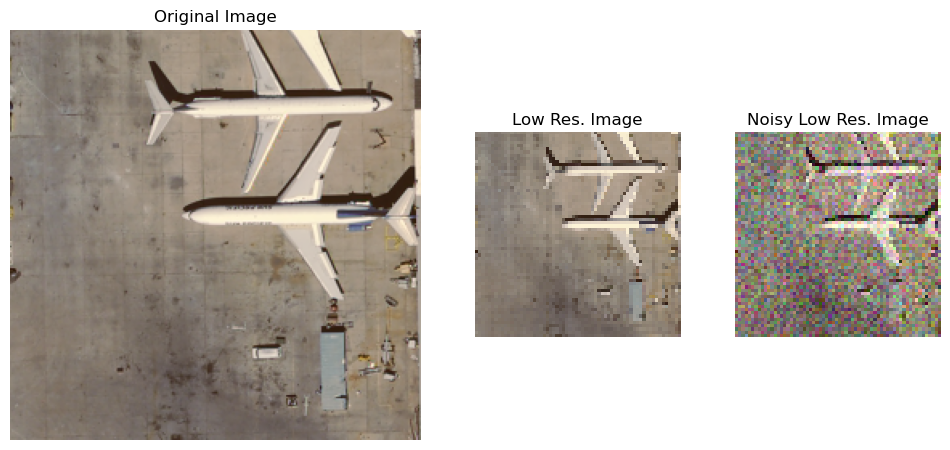

In [19]:
# Function to display the original, low-resolution, and noisy low-resolution images
def display_images(original, lr, lrnoisy):
    """
    Display the original high-resolution, low-resolution, 
    and noisy low-resolution images side by side.

    Parameters:
    - original (Tensor): The original high-resolution image tensor.
    - lr (Tensor): The downsampled low-resolution image tensor.
    - lrnoisy (Tensor): The noisy low-resolution image tensor.
    """
    # Convert tensors to numpy arrays and rearrange dimensions to (H, W, C) for matplotlib
    original = original.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    lr = lr.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    lrnoisy = lrnoisy.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    
    # Create a figure with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 0.5, 0.5]})
    
    # Plot the original high-resolution image
    axs[0].imshow(original)
    axs[0].set_title('Original Image')
    axs[0].axis('off')
    
    # Plot the low-resolution image
    axs[1].imshow(lr)
    axs[1].set_title('Low Res. Image')
    axs[1].axis('off')
    
    # Plot the noisy low-resolution image
    axs[2].imshow(lrnoisy)
    axs[2].set_title('Noisy Low Res. Image')
    axs[2].axis('off') 

    # Display the images
    plt.show()

# Call the function to display the images
display_images(hr_image, lr_image, noisy_lr_image)

## 4. Train the Network for Super-Resolution

We will train the network to upscale the low-resolution image to its high-resolution counterpart by minimizing the Mean Squared Error (MSE) between the restored and original high-resolution images.

Let's define the training loop.

In [20]:
# Function to train the DIPNet model
def train(model, noisy_lr_image, hr_image, num_epochs=2000, learning_rate=0.001):
    """
    Train the model to reconstruct the high-resolution image from a noisy low-resolution input.

    Parameters:
    - model (nn.Module): The neural network model to train.
    - noisy_lr_image (Tensor): Input noisy low-resolution image tensor.
    - hr_image (Tensor): Target high-resolution image tensor.
    - num_epochs (int, optional): Number of training epochs.
    - learning_rate (float, optional): Learning rate for the optimizer.

    Returns:
    - model (nn.Module): The trained model.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        
        # Forward pass
        restored_image = model(noisy_lr_image)
        
        # Compute loss between output and target HR image
        loss = criterion(restored_image, hr_image)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Print loss every 100 epochs
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')
    
    return model

# Initialize and train the model
model = DIPNet().to(device)
trained_model = train(model, noisy_lr_image, hr_image)


Epoch [100/2000], Loss: 0.0070
Epoch [200/2000], Loss: 0.0043
Epoch [300/2000], Loss: 0.0038
Epoch [400/2000], Loss: 0.0034
Epoch [500/2000], Loss: 0.0033
Epoch [600/2000], Loss: 0.0032
Epoch [700/2000], Loss: 0.0037
Epoch [800/2000], Loss: 0.0031
Epoch [900/2000], Loss: 0.0031
Epoch [1000/2000], Loss: 0.0029
Epoch [1100/2000], Loss: 0.0029
Epoch [1200/2000], Loss: 0.0029
Epoch [1300/2000], Loss: 0.0033
Epoch [1400/2000], Loss: 0.0028
Epoch [1500/2000], Loss: 0.0028
Epoch [1600/2000], Loss: 0.0028
Epoch [1700/2000], Loss: 0.0029
Epoch [1800/2000], Loss: 0.0027
Epoch [1900/2000], Loss: 0.0027
Epoch [2000/2000], Loss: 0.0027


## 5. Evaluate and Display the Results

After training, we will use the model to upscale the low-resolution image and visualize the results. This will help us assess how well the network has restored the image.

Let's visualize the original, low-resolution, and restored images.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0022009076..1.1071551].


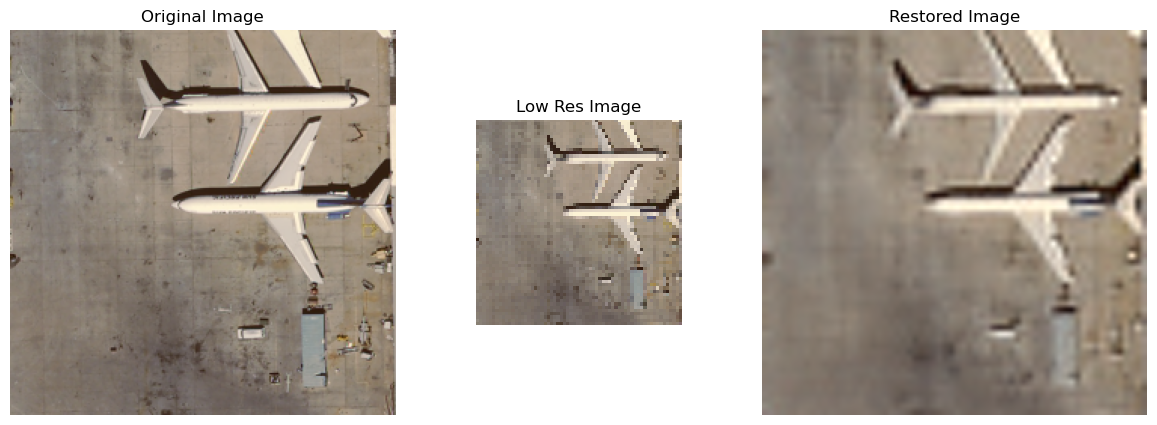

In [21]:
# Function to display the original, low-resolution, and restored images side by side
def display_images(original, lr, restored):
    """
    Display the original high-resolution image, low-resolution image, and the restored image side by side.

    Parameters:
    - original (Tensor): The original high-resolution image tensor.
    - lr (Tensor): The low-resolution image tensor.
    - restored (Tensor): The restored image tensor produced by the model.
    """
    # Convert tensors to numpy arrays and rearrange dimensions for matplotlib
    original = original.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    lr = lr.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    restored = restored.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    
    # Create a figure with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 0.5, 1]})
    
    # Plot the original high-resolution image
    axs[0].imshow(original)
    axs[0].set_title('Original Image')
    axs[0].axis('off')
    
    # Plot the low-resolution image
    axs[1].imshow(lr)
    axs[1].set_title('Low Res Image')
    axs[1].axis('off')
    
    # Plot the restored (super-resolved) image
    axs[2].imshow(restored)
    axs[2].set_title('Restored Image')
    axs[2].axis('off')
    
    # Display the plots
    plt.show()

# Set model to evaluation mode
model.eval()

# Disable gradient computation for inference
with torch.no_grad():
    restored_image = model(noisy_lr_image)

# Display original, low-resolution, and restored images
display_images(hr_image, lr_image, restored_image)

# Conclusion

In this notebook, we implemented Deep Image Prior (DIP) for super-resolution. We defined a simple neural network, prepared the data, trained the network to upscale low-resolution images, and visualized the results.

Feel free to modify the network architecture, training parameters, or test with different images to explore the capabilities of Deep Image Prior.